In [5]:
# IMPORT STATEMENTS
import re
import numpy as np
from matplotlib import pyplot as plt
get_ipython().magic('matplotlib inline')
import pandas as pd
from collections import Counter
import os
import sys
import seaborn as sns
from scipy.stats import fisher_exact, ttest_ind
sys.path.append("/home/saptarshi.sinha/Hegemon/")
sys.path.append("/home/saptarshi.sinha/Bone/")
import StepMiner as smn
import HegemonUtil as hu
acolor = ["#00CC00", "#D8A03D","#EC008C",
          'cyan', "#B741DC", "#808285",
          'blue', 'black', 'green', 'red',
          'orange', 'brown', 'pink', 'purple']

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [6]:
import bone
reload(bone)
class MacAnalysis(bone.MacAnalysis):

    def __init__(self):
        bone.MacAnalysis.__init__(self)
   
 

    def getBorok2020at2mm(self, tn=1, tb=1):
        self.prepareData('COV389')
        atype = self.h.getSurvName('c genotype')
        atypes = ['WT', 'KO']
        ahash = {'Sftpc+/creERT2; Grp78f/f without Tmx':0,
                'Sftpc+/creERT2; Grp78f/f with Tmx':1}
        self.initData(atype, atypes, ahash)
        
    def getPG2020LungHam(self, tn=1, tb=0):
        self.prepareData("COV373",'/home/saptarshi.sinha/Hegemon/explore.conf')
        atype = self.h.getSurvName("c title")
        atype = [re.sub("[-_].*", "", str(k)) for k in atype]
        ahash = {}
        atypes = ['UN', '3', '4']
        if (tn == 2):
            atypes = ['UN', '3']
        if (tn == 3):
            atypes = ['3', '4']
        self.initData(atype, atypes, ahash)        
      
    
def plotViolinBar(ana, desc=None):
    fig = plt.figure(figsize=(5,5), dpi=100)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    ax1 = plt.subplot2grid((4, 1), (0, 0))
    ax2 = plt.subplot2grid((4, 1), (1, 0), rowspan=3)
    params = {'spaceAnn': len(ana.order)/len(ana.atypes), 'tAnn': 1, 'widthAnn':1,
              'genes': [], 'ax': ax1, 'acolor': acolor}
    ax = ana.printTitleBar(params)
    res = ana.getROCAUC()
    ax.text(len(ana.cval[0]), 4, res)
    if desc is not None:
        ax.text(-1, 2, desc, horizontalalignment='right',
                    verticalalignment='center')
    params = {'spaceAnn': len(ana.order)/len(ana.atypes), 'tAnn': 1, 'widthAnn':1,
            'genes': [], 'ax': ax2, 'acolor': acolor, 'vert': 0}
    ax = ana.printViolin(None, params)
    return fig

def plotDensityBar(ana, desc=None):
    fig = plt.figure(figsize=(4,4), dpi=100)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    ax1 = plt.subplot2grid((4, 1), (0, 0))
    ax2 = plt.subplot2grid((4, 1), (1, 0), rowspan=3)
    params = {'spaceAnn': len(ana.order)/len(ana.atypes), 'tAnn': 1, 'widthAnn':1,
              'genes': [], 'ax': ax1, 'acolor': acolor}
    ax = ana.printTitleBar(params)
    res = ana.getMetrics(ana.cval[0])
    ax.text(len(ana.cval[0]), 4, ",".join(res))
    if desc is not None:
        ax.text(-1, 2, desc, horizontalalignment='right',
                    verticalalignment='center')
    ax = ana.densityPlot(ax2, acolor)
    return fig

def processData(ana, l1, wt1, desc=None, violin=1):
    ana.orderData(l1, wt1)
    if (violin == 1):
        return plotViolinBar(ana, desc)
    return plotDensityBar(ana, desc)

def processDataDf(ana, l1, wt1, desc=None):
    fig = plt.figure(figsize=(4,4), dpi=100)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    ax1 = plt.subplot2grid((4, 1), (0, 0))
    ax2 = plt.subplot2grid((4, 1), (1, 0), rowspan=3)

    c_dict, fpr, tpr, roc_auc = bone.processGeneGroupsDf(ana, l1, wt1)
    params = {'spaceAnn': len(ana.order)/len(ana.atypes), 'tAnn': 1, 'widthAnn':1,
              'genes': [], 'ax': ax1, 'acolor': acolor}
    ax = ana.printTitleBar(params)
    res = ana.getROCAUC()
    ax.text(len(ana.cval[0]), 4, res)
    if desc is not None:
        ax.text(-1, 2, desc, horizontalalignment='right',
                    verticalalignment='center')
    params = {'spaceAnn': len(ana.order)/len(ana.atypes), 'tAnn': 1, 'widthAnn':1,
            'genes': [], 'ax': ax2, 'acolor': acolor, 'vert': 0}
    ax = ana.printViolin(None, params)
    return fig

def getOrder(ana, l1):
    from scipy.stats import fisher_exact, ttest_ind
    res = []
    for s in l1:
        for gn in s:
            id1 = ana.h.getBestID(ana.h.getIDs(gn).keys())
            if id1 is None:
                continue
            e = ana.h.getExprData(id1)
            v1 = np.array([float(e[i]) if e[i] != "" else 0 for i in ana.state[0]])
            v2 = np.array([float(e[i]) if e[i] != "" else 0 for i in ana.state[1]])
            t, p = ttest_ind(v1,v2,equal_var=False)
            res += [[id1, ana.h.getSimpleName(id1),
                   t, p, np.mean(v1)-np.mean(v2)]]
    return pd.DataFrame(res, columns=['ProbeID', 'Name', 'T', 'p', 'Diff'])
def plotVolcano(ana, genes, cfile, ylim=[0, 10.5], xlim=[-6, 6]):
    df = processGenes(ana.h, [ana.state[0], ana.state[1]], genes)
    df['Size'] = 10
    fig,ax = plt.subplots(figsize=(6,4), dpi=100)
    crcdf = pd.read_csv(cfile)
    crcdf['logp'] = -np.log10(crcdf['pvalue'])
    ax = sns.scatterplot('log2FoldChange', 'logp', size=0.1, color='0.8',
                         edgecolor="none", data=crcdf)
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.legend().set_visible(False)
    import io
    import base64
    buffer = io.BytesIO()
    fig.savefig(buffer, format='jpg')
    buffer.seek(0)
    volcano = base64.b64encode(buffer.read())
    from PIL import Image, ImageDraw
    buffer.seek(0)
    img = Image.open(buffer)
    x = list(ax.bbox.bounds)
    x[2] = x[2] + x[0]
    x[3] = x[3] + x[1] - 2
    x[1] = x[1] - 2
    img = img.crop(x)

    fig,ax = plt.subplots(figsize=(6,4), dpi=100)
    ax = sns.scatterplot('Diff', 'logp', hue='Diff', palette='vlag',
                         data=df, size='Size', size_norm=(0, 10), 
                         edgecolor="none", zorder=2, ax=ax)
    ax.legend().set_visible(False)
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    for i in df.index:
        ax.text(df['Diff'][i]+.02, df['logp'][i], str(df['Name'][i]))
    ax.imshow(img,
              aspect = ax.get_aspect(),
              extent = ax.get_xlim() + ax.get_ylim(),
              zorder = 1) #put the map under the heatmap
    return ax

def savePList(ofile, ana, l1):
    df = getOrder(ana, l1)
    df1 = df.sort_values(by=['T'], ascending=True)
    bone.saveList(ofile, df1['Name'])

def getSViP():
    l1 = [bone.readList("/booleanfs2/sahoo/Data/Macrophage/BN/covid/iav-list-1.txt")[0:20]] # 20 gene signature
    wt1 = [1]
    return wt1, l1

def getViP():
    l1 = [bone.readList("/booleanfs2/sahoo/Data/Macrophage/BN/covid/list-2.txt")] # 166 gene signature
    wt1 = [1]
    return wt1, l1

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
def getPDF(cfile):
    import bone
    reload(bone)
    from matplotlib.backends.backend_pdf import PdfPages

    pdf = PdfPages(cfile)
    return pdf

def closePDF(pdf):
    import datetime
    d = pdf.infodict()
    d['Title'] = 'Plots'
    d['Author'] = 'Daniella Vo'
    d['Subject'] = "Microbe Polyp"
    d['Keywords'] = 'disease training validation ROC'
    d['CreationDate'] = datetime.datetime(2021, 1, 18)
    d['ModDate'] = datetime.datetime.today()
    pdf.close()

MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
34 16 18 0 MF2025
[636]
[392]
[539]
[370]
[494]
[314]
[889]
[546]
[674]
[828]
[177]
MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
25 2 23 0 MF2025
[636]
[392]
[539]
[370]
[494]
[314]
[889]
[546]
[674]
[828]
[177]
MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
11 2 9 0 MF2025
[636]
[392]
[539]
[370]
[494]
[314]
[889]
[546]
[674]
[828]
[177]
MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
34 2 23 9 MF2025
[636]
[392]
[539]
[370]
[494]
[314]
[889]
[546]
[674]
[828]
[177]


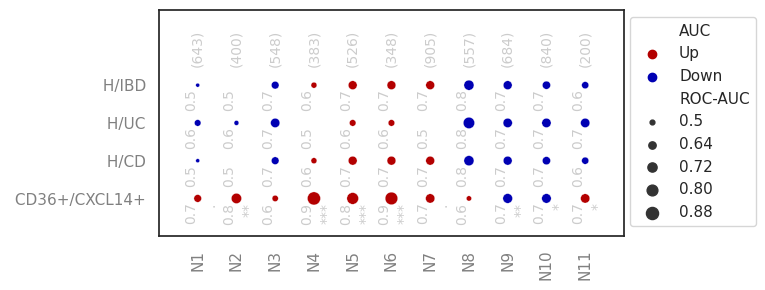

In [7]:
def IPFAnalysis(ana, desc, pdf, id1 = None):
    def getL(l1):
        return '(' + ",".join([str(len(k)) for k in l1]) +')'
    
    res = []


#    wt1, l1 = [1], [['IL15', 'IL15RA']]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IL15/RA', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
    
    
    
#    cfile = 'ipf/IPF 15-gene signature UP in IPF.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    cfile = 'ipf/IPF signature_PMID_28942086.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:8], l1[10:]]
#    wt1, l1 = [1], [bone.getEntries("/home/saptarshi.sinha/BoNE/PMID32750316-datp.txt", 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','DATP(32750316)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    wt1, l1 = [1], [bone.getEntries("/home/saptarshi.sinha/BoNE/PMID_32991815-AT2-senescence.txt", 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','AT2-senescence(32991815)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]

#    cfile = 'ipf/IPF signature_Bayesian 153 gene DOWN ONLY_PMID_21974901.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF:153dn(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_Bayesian 153 gene UP ONLY PMID_21974901.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF:153up(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature Bayesian 70 gene _PMID_21974901.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:55], l1[58:]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_25029475.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(25029475)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_28484236.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:16], l1[20:-2]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(28484236)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_30998768.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:5], l1[7:]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(30998768)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'Mayo_clusters/N1.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N1', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'Mayo_clusters/N2.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N2', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]    
    
    cfile = 'Mayo_clusters/N3.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N3', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'Mayo_clusters/N4.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N4', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'Mayo_clusters/N5.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N5', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'Mayo_clusters/N6.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N6', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'Mayo_clusters/N7.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N7', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'Mayo_clusters/N8.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N8', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'Mayo_clusters/N9.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N9', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'Mayo_clusters/NN.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N10', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'Mayo_clusters/N11.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','N11', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]      
    
    cols = ['GSEID', 'ROC-AUC', 'pvalue', '#Cont', '#Expt',
            'Series', 'Species', 'Signature', '#Genes']
    df = pd.DataFrame(res, columns=cols)
    df['Condition'] = desc
    return df

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
def getPDF(cfile):
    import bone
    reload(bone)
    from matplotlib.backends.backend_pdf import PdfPages

    pdf = PdfPages(cfile)
    return pdf

def closePDF(pdf):
    import datetime
    d = pdf.infodict()
    d['Title'] = 'Plots'
    d['Author'] = 'Daniella Vo'
    d['Subject'] = "Microbe Polyp"
    d['Keywords'] = 'disease training validation ROC'
    d['CreationDate'] = datetime.datetime(2021, 1, 18)
    d['ModDate'] = datetime.datetime.today()
    pdf.close()

def IPFBubble(dfs):
    if len(dfs) <= 0:
        return None
    df1 = dfs[0]
    df1['Name'] = list(df1['Signature'])
    df1['Xl'] = list(df1['#Genes'])
    labels = [k['GSEID'][0] + ' ' + k['Condition'][0] for k in dfs]
    n1 = df1.shape[0]
    rocauc = list(df1['ROC-AUC'])
    p = list(df1['pvalue'])
    y = [1] * n1
    for i in range(1, len(dfs)):
        rocauc += list(dfs[i]['ROC-AUC'])
        p += list(dfs[i]['pvalue'])
        y += [i+1] * n1
    df = pd.DataFrame()
    df['ROC-AUC'] = rocauc
    df['pvalue'] = p
    df['ROC-AUC'] = df['ROC-AUC'].apply(
               lambda x: max([float(k) for k in str(x).split(",")]))
    df['pvalue'] = df['pvalue'].apply(
               lambda x: min([float(k) for k in str(x).split(",")]))
    df['Y'] = y
    df['R'] = df['ROC-AUC'] - 0.5
    df['Ra'] = abs(df['R']) + 0.5
    df['AUC'] = ['Up' if i > 0 else 'Down' for i in df['R']]
    df['code'] = [bone.getCode(i) for i in df['pvalue']]
    df['ROC-AUC'] = df['Ra']
    sns.set()
    sns.set_style("white")
    sns.set_style({'xtick.color':'.5', 'ytick.color':'.5', 'axes.labelcolor': '.5'})
    sns.set_context("notebook")
    sns.set_palette([bone.adj_light(c, 0.7, 1) for c in ['red', 'blue']])
    x = [i + 1 for i in range(n1)] * len(labels)
    y = df['Y']
    fig, ax = plt.subplots(figsize=(6, len(dfs)*0.5+1), dpi=100)
    ax = sns.scatterplot(x=x, y=y, size="ROC-AUC", hue='AUC',
                         sizes = (0, 100), size_norm = (0.5, 1),
                         hue_order = ['Up', 'Down'], ax=ax, data=df);
    roc = list(df['Ra'])
    code = list(df['code'])
    for line in range(n1):
        ax.text(line + 1, len(labels) + .5, df1['Xl'][line],
                horizontalalignment='center', size='small', color='0.8',
                verticalalignment='bottom', rotation=90)
        for i in range(len(labels)):
            ax.text(line + 1, i + 0.9, "%.1f" % roc[line + n1 * i],
                    horizontalalignment='right', size='small', color='0.8',
                    verticalalignment='top',  rotation=90)
            ax.text(line + 1.5, i + 0.9, code[line + n1 * i],
                    horizontalalignment='right', size='small', color='0.8',
                    verticalalignment='top',  rotation=90)

    x1 = [i + 1 for i in range(n1)]
    ax.set_yticks(range(1, len(labels) + 1))
    ax.set_yticklabels(labels)
    ax.set_xlim([0, len(x1)+1])
    ax.set_ylim([0, len(labels) + 2])
    ax.set_xticks(x1)
    ax.set_xticklabels(df1['Name'], rotation=90)
    ax.set_ylabel("")
    ax.grid(False)
    handles, labels = ax.get_legend_handles_labels()
    labels[4] = '0.5'
    ax.legend(handles, labels, bbox_to_anchor=(1.3, 1))

    return df,ax

import bone
reload(bone)
cfile = "MF_RNAvel_dotplot.pdf"
pdf = getPDF(cfile)
ana = bone.MacAnalysis()
res = []

#ana.getXu2020CoV2(3)
#res += [IPFAnalysis(ana, 'CoV2')]
#ana.getXu2020CoV2(4)
#res += [IPFAnalysis(ana, 'IPF')]
#ana.getXu2020CoV2(5)
#res += [IPFAnalysis(ana, 'IPF-CoV2')]
#ana.getMelms2021CoV2snblk()
#res += [IPFAnalysis(ana, 'lungCoV2')]
#ana.getBharat2020CoV2scblk(2, 0)
#res += [IPFAnalysis(ana, 'epiCoV2')]
#ana.getNienhold2020(2)
#res += [IPFAnalysis(ana, 'lungCoV2')]


#ana.getWinkler2021CoV2hACE2mm()
#res += [IPFAnalysis(ana, 'hACE2mm', pdf)]
#ana.getdobosh2021()
#res += [IPFAnalysis(ana, '24 hours__Infection_no_transmigration', pdf)]
#ana.getdobosh2021(2)
#res += [IPFAnalysis(ana, '24 hours__Infection_transmigration', pdf)]


ana.getMF2025_final()
res += [IPFAnalysis(ana, 'CD36+/CXCL14+', pdf)]
ana.getMF2025_final_H_CD()
res += [IPFAnalysis(ana, 'H/CD', pdf)]
ana.getMF2025_final_H_UC()
res += [IPFAnalysis(ana, 'H/UC', pdf)]
ana.getMF2025_final_H_IBD()
res += [IPFAnalysis(ana, 'H/IBD', pdf)]




df,ax = IPFBubble(res)
pdf.savefig(transparent=True,bbox_inches = 'tight')
closePDF(pdf)


MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
34 16 18 0 MF2025
[27]
[15]
[15]
[24]
[10]
[10]
[16]
[15]
[12]
[9]
[15]
[10]
[6]
[16]
[6]
[7]
[6]
[7]
[15]
[15]
MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
25 2 23 0 MF2025
[27]
[15]
[15]
[24]
[10]
[10]
[16]
[15]
[12]
[9]
[15]
[10]
[6]
[16]
[6]
[7]
[6]
[7]
[15]
[15]
MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
11 2 9 0 MF2025
[27]
[15]
[15]
[24]
[10]
[10]
[16]
[15]
[12]
[9]
[15]
[10]
[6]
[16]
[6]
[7]
[6]
[7]
[15]
[15]
MF2025 (n = 100)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=MF2025
34 2 23 9 MF2025
[27]
[15]
[15]
[24]
[10]
[10]
[16]
[15]
[12]
[9]
[15]
[10]
[6]
[16]
[6]
[7]
[6]
[7]
[15]
[15]


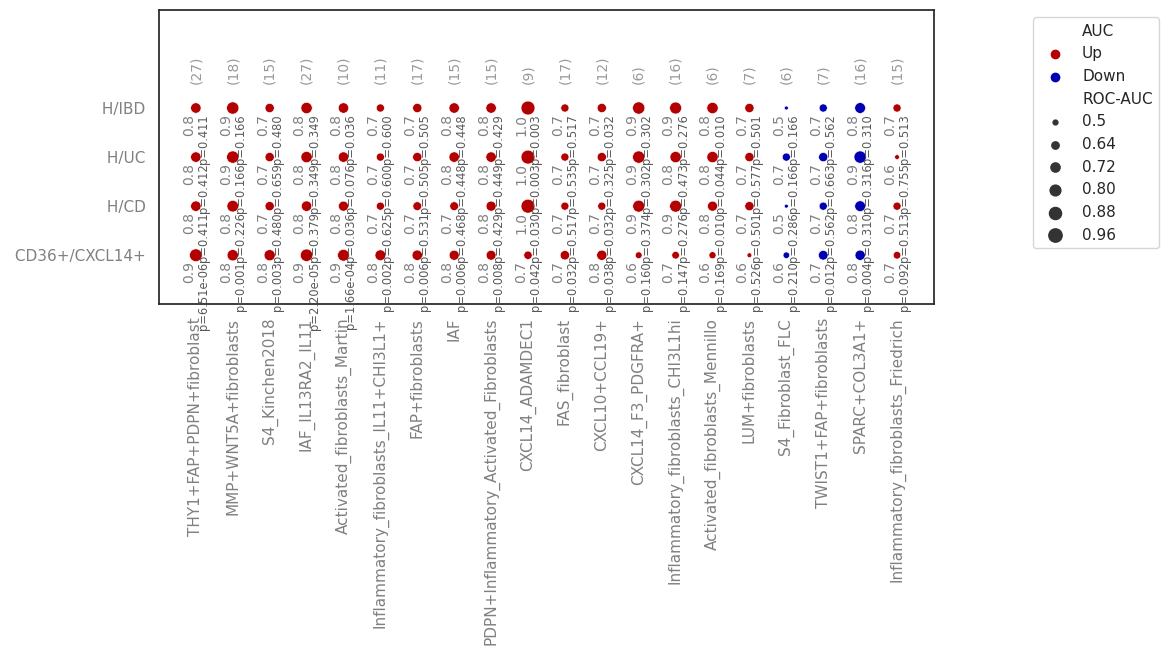

In [3]:
def IPFAnalysis(ana, desc, pdf, id1 = None):
    def getL(l1):
        return '(' + ",".join([str(len(k)) for k in l1]) +')'
    
    res = []


#    wt1, l1 = [1], [['IL15', 'IL15RA']]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IL15/RA', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
    
    
    
#    cfile = 'ipf/IPF 15-gene signature UP in IPF.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    cfile = 'ipf/IPF signature_PMID_28942086.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:8], l1[10:]]
#    wt1, l1 = [1], [bone.getEntries("/home/saptarshi.sinha/BoNE/PMID32750316-datp.txt", 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','DATP(32750316)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    wt1, l1 = [1], [bone.getEntries("/home/saptarshi.sinha/BoNE/PMID_32991815-AT2-senescence.txt", 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','AT2-senescence(32991815)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]

#    cfile = 'ipf/IPF signature_Bayesian 153 gene DOWN ONLY_PMID_21974901.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF:153dn(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_Bayesian 153 gene UP ONLY PMID_21974901.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF:153up(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature Bayesian 70 gene _PMID_21974901.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:55], l1[58:]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_25029475.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(25029475)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_28484236.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:16], l1[20:-2]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(28484236)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_30998768.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:5], l1[7:]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(30998768)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/THY1+FAP+PDPN+fibroblast.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','THY1+FAP+PDPN+fibroblast', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/MMP+WNT5A+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','MMP+WNT5A+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]    
    
    cfile = 'sig/S4_Kinchen2018.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','S4_Kinchen2018', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/IAF_IL13RA2_IL11+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IAF_IL13RA2_IL11', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/Activated_fibroblasts_Martin.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Activated_fibroblasts_Martin', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'sig/Inflammatory_fibroblasts_IL11+CHI3L1+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Inflammatory_fibroblasts_IL11+CHI3L1+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/FAP+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','FAP+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/IAF.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IAF', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/PDPN+Inflammatory_Activated_Fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','PDPN+Inflammatory_Activated_Fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/CXCL14_ADAMDEC1.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','CXCL14_ADAMDEC1', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'sig/FAS_fibroblast.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','FAS_fibroblast', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]    
    
    cfile = 'sig/CXCL10+CCL19+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','CXCL10+CCL19+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/CXCL14_F3_PDGFRA+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','CXCL14_F3_PDGFRA+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/Inflammatory_fibroblasts_CHI3L1hi.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Inflammatory_fibroblasts_CHI3L1hi', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/Activated_fibroblasts_Mennillo.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Activated_fibroblasts_Mennillo', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/LUM+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','LUM+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/S4_Fibroblast_FLC.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','S4_Fibroblast_FLC', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/TWIST1+FAP+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','TWIST1+FAP+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'sig/SPARC+COL3A1+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','SPARC+COL3A1+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/Inflammatory_fibroblasts_Friedrich.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Inflammatory_fibroblasts_Friedrich', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]     
    
    cols = ['GSEID', 'ROC-AUC', 'pvalue', '#Cont', '#Expt',
            'Series', 'Species', 'Signature', '#Genes']
    df = pd.DataFrame(res, columns=cols)
    df['Condition'] = desc
    return df

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
def getPDF(cfile):
    import bone
    reload(bone)
    from matplotlib.backends.backend_pdf import PdfPages

    pdf = PdfPages(cfile)
    return pdf

def closePDF(pdf):
    import datetime
    d = pdf.infodict()
    d['Title'] = 'Plots'
    d['Author'] = 'Daniella Vo'
    d['Subject'] = "Microbe Polyp"
    d['Keywords'] = 'disease training validation ROC'
    d['CreationDate'] = datetime.datetime(2021, 1, 18)
    d['ModDate'] = datetime.datetime.today()
    pdf.close()

def IPFBubble(dfs):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import bone

    if len(dfs) <= 0:
        return None

    df1 = dfs[0].copy()
    df1['Name'] = list(df1['Signature'])
    df1['Xl'] = list(df1['#Genes'])

    labels = [k['GSEID'].iloc[0] + ' ' + k['Condition'].iloc[0] for k in dfs]
    n1 = df1.shape[0]

    rocauc = list(df1['ROC-AUC'])
    p = list(df1['pvalue'])
    y = [1] * n1

    for i in range(1, len(dfs)):
        rocauc += list(dfs[i]['ROC-AUC'])
        p += list(dfs[i]['pvalue'])
        y += [i + 1] * n1

    df = pd.DataFrame()
    df['ROC-AUC'] = rocauc
    df['pvalue'] = p

    # If a cell contains multiple comma-separated AUCs or p-values,
    # keep the strongest summary exactly as in your original code:
    # max AUC and min p-value
    df['ROC-AUC'] = df['ROC-AUC'].apply(
        lambda x: max([float(k) for k in str(x).split(",")])
    )
    df['pvalue'] = df['pvalue'].apply(
        lambda x: min([float(k) for k in str(x).split(",")])
    )

    df['Y'] = y
    df['R'] = df['ROC-AUC'] - 0.5
    df['Ra'] = abs(df['R']) + 0.5
    df['AUC'] = ['Up' if i > 0 else 'Down' for i in df['R']]

    # Optional star code retained in dataframe, though not displayed
    df['code'] = [bone.getCode(i) for i in df['pvalue']]

    # Numeric p-value text for plotting
    def format_pvalue(x):
        if x < 0.001:
            return f"p={x:.2e}"
        return f"p={x:.3f}"

    df['ptext'] = df['pvalue'].apply(format_pvalue)

    # Bubble size uses adjusted AUC as before
    df['ROC-AUC'] = df['Ra']

    sns.set()
    sns.set_style("white")
    sns.set_style({
        'xtick.color': '.5',
        'ytick.color': '.5',
        'axes.labelcolor': '.5'
    })
    sns.set_context("notebook")
    sns.set_palette([bone.adj_light(c, 0.7, 1) for c in ['red', 'blue']])

    x = [i + 1 for i in range(n1)] * len(labels)
    y = df['Y']

    fig, ax = plt.subplots(figsize=(10, len(dfs) * 0.6 + 1.5), dpi=100)

    ax = sns.scatterplot(
        x=x,
        y=y,
        size="ROC-AUC",
        hue='AUC',
        sizes=(0, 100),
        size_norm=(0.5, 1),
        hue_order=['Up', 'Down'],
        ax=ax,
        data=df
    )

    roc = list(df['Ra'])
    ptext = list(df['ptext'])

    for line in range(n1):
        # gene count at top
        ax.text(
            line + 1,
            len(labels) + 0.5,
            str(df1['Xl'].iloc[line]),
            horizontalalignment='center',
            size='small',
            color='0.6',
            verticalalignment='bottom',
            rotation=90
        )

        for i in range(len(labels)):
            idx = line + n1 * i

            # show AUC value
            ax.text(
                line + 1,
                i + 0.88,
                f"{roc[idx]:.1f}",
                horizontalalignment='right',
                size='small',
                color='0.5',
                verticalalignment='top',
                rotation=90
            )

            # show numeric p-value
            ax.text(
                line + 1.38,
                i + 0.88,
                ptext[idx],
                horizontalalignment='right',
                size='x-small',
                color='0.35',
                verticalalignment='top',
                rotation=90
            )

    x1 = [i + 1 for i in range(n1)]
    ax.set_yticks(range(1, len(labels) + 1))
    ax.set_yticklabels(labels)
    ax.set_xlim([0, len(x1) + 1])
    ax.set_ylim([0, len(labels) + 2])
    ax.set_xticks(x1)
    ax.set_xticklabels(df1['Name'], rotation=90)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.grid(False)

    handles, legend_labels = ax.get_legend_handles_labels()
    if len(legend_labels) > 4:
        legend_labels[4] = '0.5'
    ax.legend(handles, legend_labels, bbox_to_anchor=(1.3, 1))

    return df, ax

import bone
reload(bone)
cfile = "MF_cross_cohort_beanchmarking.pdf"
pdf = getPDF(cfile)
ana = bone.MacAnalysis()
res = []

#ana.getXu2020CoV2(3)
#res += [IPFAnalysis(ana, 'CoV2')]
#ana.getXu2020CoV2(4)
#res += [IPFAnalysis(ana, 'IPF')]
#ana.getXu2020CoV2(5)
#res += [IPFAnalysis(ana, 'IPF-CoV2')]
#ana.getMelms2021CoV2snblk()
#res += [IPFAnalysis(ana, 'lungCoV2')]
#ana.getBharat2020CoV2scblk(2, 0)
#res += [IPFAnalysis(ana, 'epiCoV2')]
#ana.getNienhold2020(2)
#res += [IPFAnalysis(ana, 'lungCoV2')]


#ana.getWinkler2021CoV2hACE2mm()
#res += [IPFAnalysis(ana, 'hACE2mm', pdf)]
#ana.getdobosh2021()
#res += [IPFAnalysis(ana, '24 hours__Infection_no_transmigration', pdf)]
#ana.getdobosh2021(2)
#res += [IPFAnalysis(ana, '24 hours__Infection_transmigration', pdf)]


ana.getMF2025_final()
res += [IPFAnalysis(ana, 'CD36+/CXCL14+', pdf)]
ana.getMF2025_final_H_CD()
res += [IPFAnalysis(ana, 'H/CD', pdf)]
ana.getMF2025_final_H_UC()
res += [IPFAnalysis(ana, 'H/UC', pdf)]
ana.getMF2025_final_H_IBD()
res += [IPFAnalysis(ana, 'H/IBD', pdf)]




df,ax = IPFBubble(res)
pdf.savefig(transparent=True,bbox_inches = 'tight')
closePDF(pdf)


EDNRB2026 (n = 11)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=EDNRB2026
5 3 2 0 EDNRB2026
[26]
[14]
[11]
[24]
[8]
[10]
[13]
[15]
[12]
[9]
[14]
[5]
[6]
[10]
[5]
[7]
[6]
[7]
[15]
[11]
EDNRB2026 (n = 11)
 http://hegemon.ucsd.edu/Tools/explore.php?key=blood:leukemia&id=EDNRB2026
4 2 2 0 EDNRB2026
[26]
[14]
[11]
[24]
[8]
[10]
[13]
[15]
[12]
[9]
[14]
[5]
[6]
[10]
[5]
[7]
[6]
[7]
[15]
[11]


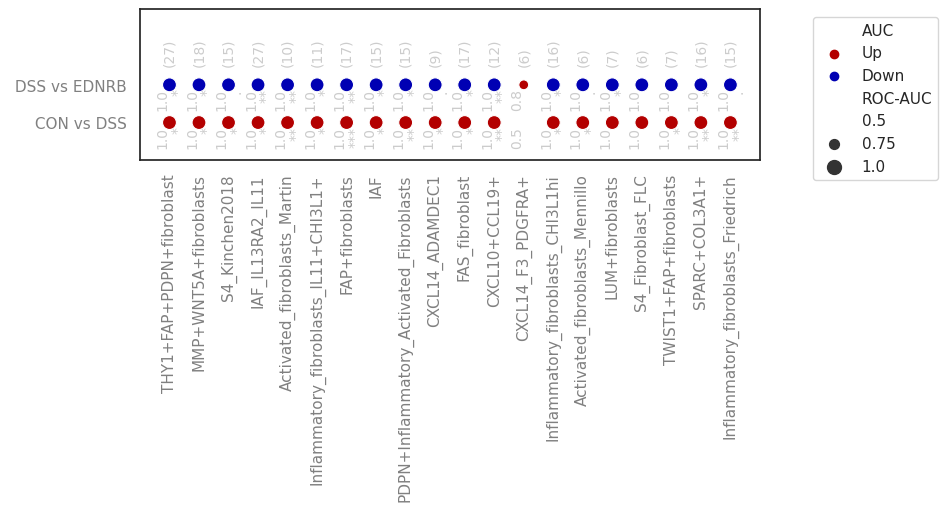

In [4]:
def IPFAnalysis(ana, desc, pdf, id1 = None):
    def getL(l1):
        return '(' + ",".join([str(len(k)) for k in l1]) +')'
    
    res = []


#    wt1, l1 = [1], [['IL15', 'IL15RA']]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IL15/RA', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
    
    
    
#    cfile = 'ipf/IPF 15-gene signature UP in IPF.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    cfile = 'ipf/IPF signature_PMID_28942086.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:8], l1[10:]]
#    wt1, l1 = [1], [bone.getEntries("/home/saptarshi.sinha/BoNE/PMID32750316-datp.txt", 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','DATP(32750316)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    wt1, l1 = [1], [bone.getEntries("/home/saptarshi.sinha/BoNE/PMID_32991815-AT2-senescence.txt", 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','AT2-senescence(32991815)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]

#    cfile = 'ipf/IPF signature_Bayesian 153 gene DOWN ONLY_PMID_21974901.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF:153dn(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_Bayesian 153 gene UP ONLY PMID_21974901.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF:153up(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature Bayesian 70 gene _PMID_21974901.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:55], l1[58:]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(21974901)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_25029475.txt'
#    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(25029475)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_28484236.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:16], l1[20:-2]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(28484236)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
#    cfile = 'ipf/IPF signature_PMID_30998768.txt'
#    l1 = bone.getEntries(cfile, 0)
#    wt1, l1 = [1, -1], [l1[1:5], l1[7:]]
#    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IPF(30998768)', getL(l1)]
#    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/THY1+FAP+PDPN+fibroblast.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','THY1+FAP+PDPN+fibroblast', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/MMP+WNT5A+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','MMP+WNT5A+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]    
    
    cfile = 'sig/S4_Kinchen2018.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','S4_Kinchen2018', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/IAF_IL13RA2_IL11+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IAF_IL13RA2_IL11', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/Activated_fibroblasts_Martin.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Activated_fibroblasts_Martin', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'sig/Inflammatory_fibroblasts_IL11+CHI3L1+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Inflammatory_fibroblasts_IL11+CHI3L1+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/FAP+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','FAP+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/IAF.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','IAF', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/PDPN+Inflammatory_Activated_Fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','PDPN+Inflammatory_Activated_Fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]  
    
    cfile = 'sig/CXCL14_ADAMDEC1.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','CXCL14_ADAMDEC1', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'sig/FAS_fibroblast.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','FAS_fibroblast', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]    
    
    cfile = 'sig/CXCL10+CCL19+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','CXCL10+CCL19+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/CXCL14_F3_PDGFRA+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','CXCL14_F3_PDGFRA+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/Inflammatory_fibroblasts_CHI3L1hi.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Inflammatory_fibroblasts_CHI3L1hi', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/Activated_fibroblasts_Mennillo.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Activated_fibroblasts_Mennillo', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/LUM+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','LUM+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/S4_Fibroblast_FLC.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','S4_Fibroblast_FLC', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cfile = 'sig/TWIST1+FAP+fibroblasts.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','TWIST1+FAP+fibroblasts', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]   
    
    cfile = 'sig/SPARC+COL3A1+.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','SPARC+COL3A1+', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)] 
    
    cfile = 'sig/Inflammatory_fibroblasts_Friedrich.txt'
    wt1, l1 = [1], [bone.getEntries(cfile, 0)[:-1]]
    ann = [re.sub(" .*", "", ana.h.getSource()),'Hs','Inflammatory_fibroblasts_Friedrich', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]     
    
    cols = ['GSEID', 'ROC-AUC', 'pvalue', '#Cont', '#Expt',
            'Series', 'Species', 'Signature', '#Genes']
    df = pd.DataFrame(res, columns=cols)
    df['Condition'] = desc
    return df

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
def getPDF(cfile):
    import bone
    reload(bone)
    from matplotlib.backends.backend_pdf import PdfPages

    pdf = PdfPages(cfile)
    return pdf

def closePDF(pdf):
    import datetime
    d = pdf.infodict()
    d['Title'] = 'Plots'
    d['Author'] = 'Daniella Vo'
    d['Subject'] = "Microbe Polyp"
    d['Keywords'] = 'disease training validation ROC'
    d['CreationDate'] = datetime.datetime(2021, 1, 18)
    d['ModDate'] = datetime.datetime.today()
    pdf.close()

def IPFBubble(dfs):
    if len(dfs) <= 0:
        return None
    df1 = dfs[0]
    df1['Name'] = list(df1['Signature'])
    df1['Xl'] = list(df1['#Genes'])
    labels = [k['GSEID'][0] + ' ' + k['Condition'][0] for k in dfs]
    n1 = df1.shape[0]
    rocauc = list(df1['ROC-AUC'])
    p = list(df1['pvalue'])
    y = [1] * n1
    for i in range(1, len(dfs)):
        rocauc += list(dfs[i]['ROC-AUC'])
        p += list(dfs[i]['pvalue'])
        y += [i+1] * n1
    df = pd.DataFrame()
    df['ROC-AUC'] = rocauc
    df['pvalue'] = p
    df['ROC-AUC'] = df['ROC-AUC'].apply(
               lambda x: max([float(k) for k in str(x).split(",")]))
    df['pvalue'] = df['pvalue'].apply(
               lambda x: min([float(k) for k in str(x).split(",")]))
    df['Y'] = y
    df['R'] = df['ROC-AUC'] - 0.5
    df['Ra'] = abs(df['R']) + 0.5
    df['AUC'] = ['Up' if i > 0 else 'Down' for i in df['R']]
    df['code'] = [bone.getCode(i) for i in df['pvalue']]
    df['ROC-AUC'] = df['Ra']
    sns.set()
    sns.set_style("white")
    sns.set_style({'xtick.color':'.5', 'ytick.color':'.5', 'axes.labelcolor': '.5'})
    sns.set_context("notebook")
    sns.set_palette([bone.adj_light(c, 0.7, 1) for c in ['red', 'blue']])
    x = [i + 1 for i in range(n1)] * len(labels)
    y = df['Y']
    fig, ax = plt.subplots(figsize=(8, len(dfs)*0.5+1), dpi=100)
    ax = sns.scatterplot(x=x, y=y, size="ROC-AUC", hue='AUC',
                         sizes = (0, 100), size_norm = (0.5, 1),
                         hue_order = ['Up', 'Down'], ax=ax, data=df);
    roc = list(df['Ra'])
    code = list(df['code'])
    for line in range(n1):
        ax.text(line + 1, len(labels) + .5, df1['Xl'][line],
                horizontalalignment='center', size='small', color='0.8',
                verticalalignment='bottom', rotation=90)
        for i in range(len(labels)):
            ax.text(line + 1, i + 0.9, "%.1f" % roc[line + n1 * i],
                    horizontalalignment='right', size='small', color='0.8',
                    verticalalignment='top',  rotation=90)
            ax.text(line + 1.5, i + 0.9, code[line + n1 * i],
                    horizontalalignment='right', size='small', color='0.8',
                    verticalalignment='top',  rotation=90)

    x1 = [i + 1 for i in range(n1)]
    ax.set_yticks(range(1, len(labels) + 1))
    ax.set_yticklabels(labels)
    ax.set_xlim([0, len(x1)+1])
    ax.set_ylim([0, len(labels) + 2])
    ax.set_xticks(x1)
    ax.set_xticklabels(df1['Name'], rotation=90)
    ax.set_ylabel("")
    ax.grid(False)
    handles, labels = ax.get_legend_handles_labels()
    labels[4] = '0.5'
    ax.legend(handles, labels, bbox_to_anchor=(1.3, 1))

    return df,ax

import bone
reload(bone)
cfile = "EDNRB_DSS_cross_cohort_beanchmarking.pdf"
pdf = getPDF(cfile)
ana = bone.MacAnalysis()
res = []

#ana.getXu2020CoV2(3)
#res += [IPFAnalysis(ana, 'CoV2')]
#ana.getXu2020CoV2(4)
#res += [IPFAnalysis(ana, 'IPF')]
#ana.getXu2020CoV2(5)
#res += [IPFAnalysis(ana, 'IPF-CoV2')]
#ana.getMelms2021CoV2snblk()
#res += [IPFAnalysis(ana, 'lungCoV2')]
#ana.getBharat2020CoV2scblk(2, 0)
#res += [IPFAnalysis(ana, 'epiCoV2')]
#ana.getNienhold2020(2)
#res += [IPFAnalysis(ana, 'lungCoV2')]


#ana.getWinkler2021CoV2hACE2mm()
#res += [IPFAnalysis(ana, 'hACE2mm', pdf)]
#ana.getdobosh2021()
#res += [IPFAnalysis(ana, '24 hours__Infection_no_transmigration', pdf)]
#ana.getdobosh2021(2)
#res += [IPFAnalysis(ana, '24 hours__Infection_transmigration', pdf)]


ana.getEDNRB1()
res += [IPFAnalysis(ana, 'CON vs DSS', pdf)]
ana.getEDNRB2()
res += [IPFAnalysis(ana, 'DSS vs EDNRB', pdf)]



df,ax = IPFBubble(res)
pdf.savefig(transparent=True,bbox_inches = 'tight')
closePDF(pdf)
